In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Task 1: Data Understanding and Visualization:

1. Load and visualize images from a dataset stored in directories, where each subdirec tory represents a class. You are expected to write a code:

• Get the list of class directories from the train folder.

• Select one image randomly from each class.

• Display the images in a grid format with two rows using matplotlib.


### Setup and Data Loading



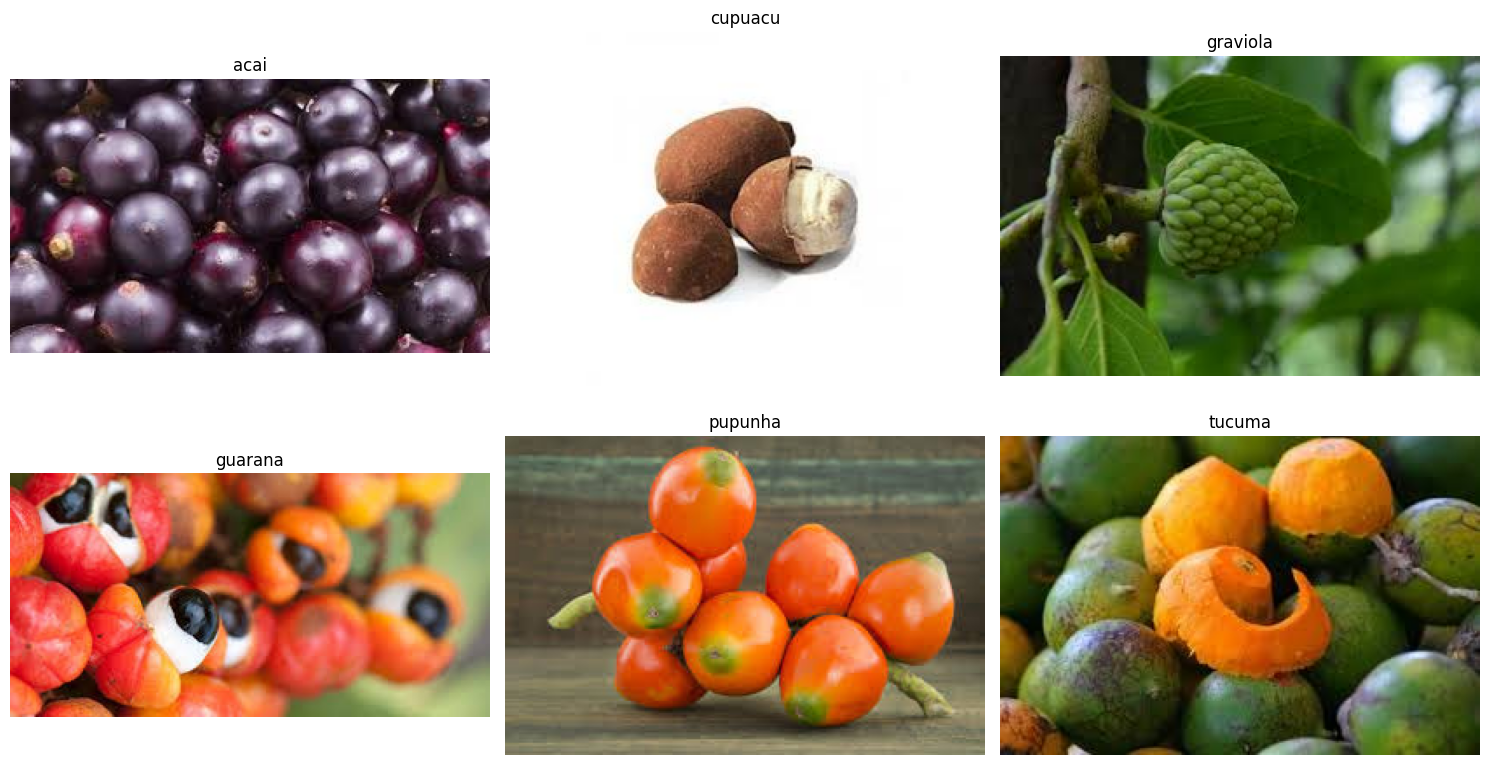

In [2]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Define dataset paths
train_dir = "/content/drive/MyDrive/AI Sem6/Worksheet5/FruitinAmazon/train/"
test_dir = "/content/drive/MyDrive/AI Sem6/Worksheet5/FruitinAmazon/test/"

# Get list of class directories from the train folder
class_dirs = sorted(os.listdir(train_dir))

# Select one image randomly from each class and store them
selected_images = []
class_names = []

for class_name in class_dirs:
    class_path = os.path.join(train_dir, class_name)
    image_files = os.listdir(class_path)

    # Select a random image from this class
    random_image = random.choice(image_files)
    img_path = os.path.join(class_path, random_image)

    # Open and store the image
    img = Image.open(img_path)
    selected_images.append(img)
    class_names.append(class_name)

# Display the images in a grid format with two rows
num_classes = len(class_dirs)
num_cols = (num_classes + 1) // 2  # Ceiling division for odd number of classes
fig, axes = plt.subplots(2, num_cols, figsize=(15, 8))

for i, (img, class_name) in enumerate(zip(selected_images, class_names)):
    row = i // num_cols
    col = i % num_cols
    axes[row, col].imshow(img)
    axes[row, col].set_title(class_name)
    axes[row, col].axis('off')

# Turn off axes for any unused subplots
for i in range(len(selected_images), 2 * num_cols):
    row = i // num_cols
    col = i % num_cols
    if row < 2 and col < num_cols:
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()


• What did you Observe?

answer: The code successfully identified 6 class directories: 'acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', and 'tucuma'. One random image was selected from each of these 6 classes, and these images were then displayed in a grid format with 2 rows, with each image labeled by its corresponding class name.

###2. Check for corrupted images:
   - Write a script that verifies whether images in the train directory are valid
   - If any corrupted images are found, remove them and print a message showing which images were removed
   - If no corrupted images are found, print "No Corrupted Images Found"
   - Hint: Use Image.open() to attempt loading each image and catch IOError or SyntaxError

In [3]:
# Initialize counter for corrupted images
corrupted_images = []

# Walk through all files in the train directory
for root, dirs, files in os.walk(train_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
            img_path = os.path.join(root, file)
            try:
                # Try to open the image
                with Image.open(img_path) as img:
                    # Verify image is valid by loading it
                    img.verify()
                    # Also try to load the image data
                    with Image.open(img_path) as img_load:
                        img_load.load()
            except (IOError, SyntaxError, OSError) as e:
                # If there's an error, the image is corrupted
                corrupted_images.append(img_path)
                print(f"Corrupted image found: {img_path}")
                # Remove the corrupted image
                os.remove(img_path)

# Print summary
if corrupted_images:
    print(f"\nRemoved {len(corrupted_images)} corrupted images:")
    for img in corrupted_images:
        print(f" - {img}")
else:
    print("No Corrupted Images Found")

No Corrupted Images Found


## Task 2: Loading and Preprocessing Image Data

- Use tf.keras.preprocessing.image_dataset_from_directory to load the datasets
- Apply proper preprocessing including:
  - Resizing images to a consistent size (e.g., 128×128)
  - Normalizing pixel values by scaling them to [0, 1]
  - Creating separate training and validation datasets
  - Using appropriate batch size
  - Implementing data augmentation (optional)

In [4]:
import tensorflow as tf

# Define image size and batch size
img_height = 128  # Example image height
img_width = 128  # Example image width
batch_size = 32
validation_split = 0.2  # 80% training, 20% validation

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1.0 / 255)  # Normalize pixel values to [0, 1]

# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=123,
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=123,
)

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


## Task 3: Implement a CNN

Implement a CNN with the following structure:

**Convolutional Architecture:**
- Convolutional Layer 1:
  - Filter Size: (3, 3)
  - Number of Filters: 32
  - Padding: same
  - Stride: 1
  - Activation: ReLU
- Pooling Layer 1:
  - Max pooling with size (2, 2) and stride 2
- Convolutional Layer 2:
  - Filter Size: (3, 3)
  - Number of Filters: 32
  - Padding: same
  - Stride: 1
  - Activation: ReLU
- Pooling Layer 2:
  - Max pooling with size (2, 2) and stride 2

**Fully Connected Network Architecture:**
- Flatten Layer
- Hidden Layer 1: 64 neurons
- Hidden Layer 2: 128 neurons
- Output Layer: num_classes neurons (number of classes in the dataset)

In [5]:
from tensorflow.keras import layers, models

# Get the number of classes from our train_ds
num_classes = len(class_dirs)

# Build the CNN model
model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(img_height, img_width, 3)),
    # Pooling Layer 1
    layers.MaxPooling2D((2, 2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    # Pooling Layer 2
    layers.MaxPooling2D((2, 2), strides=2),

    # Flatten Layer
    layers.Flatten(),

    # Hidden Layer 1
    layers.Dense(64, activation='relu'),

    # Hidden Layer 2
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Compile and Train the Model

- Compile the model with:
  - An appropriate optimizer (e.g., Adam)
  - Appropriate loss function (e.g., sparse categorical crossentropy)
  - Accuracy as the evaluation metric
- Train the model using:
  - model.fit() function
  - Batch size of 16
  - 250 epochs
  - Validation dataset for validation
  - Callbacks for ModelCheckpoint and EarlyStopping


In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
checkpoint_cb = ModelCheckpoint(
    'best_model.h5', save_best_only=True, monitor='val_loss', mode='min'
)
early_stopping_cb = EarlyStopping(
    patience=10, restore_best_weights=True, monitor='val_loss', mode='min'
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.1453 - loss: 1.8395

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 564ms/step - accuracy: 0.1389 - loss: 1.8853 - val_accuracy: 0.4444 - val_loss: 1.3937
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 461ms/step - accuracy: 0.2639 - loss: 1.6958 - val_accuracy: 0.6111 - val_loss: 1.3965
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.2986 - loss: 1.5525

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 464ms/step - accuracy: 0.3333 - loss: 1.5153 - val_accuracy: 0.7778 - val_loss: 1.2631
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.4236 - loss: 1.3151

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 812ms/step - accuracy: 0.4583 - loss: 1.2752 - val_accuracy: 0.7778 - val_loss: 0.9900
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 732ms/step - accuracy: 0.6944 - loss: 0.9983 - val_accuracy: 0.6111 - val_loss: 1.1657
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.7604 - loss: 0.8493

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 474ms/step - accuracy: 0.7500 - loss: 0.8342 - val_accuracy: 0.6667 - val_loss: 0.8289
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 455ms/step - accuracy: 0.8889 - loss: 0.5587 - val_accuracy: 0.7222 - val_loss: 0.9044
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.9097 - loss: 0.4761

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 442ms/step - accuracy: 0.9167 - loss: 0.4411 - val_accuracy: 0.7778 - val_loss: 0.6004
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.9653 - loss: 0.2352

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 483ms/step - accuracy: 0.9583 - loss: 0.2536 - val_accuracy: 0.8333 - val_loss: 0.3840
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 746ms/step - accuracy: 0.9722 - loss: 0.1441 - val_accuracy: 0.7778 - val_loss: 0.6225
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 692ms/step - accuracy: 0.9722 - loss: 0.1173 - val_accuracy: 0.8333 - val_loss: 0.6374
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 489ms/step - accuracy: 0.9861 - loss: 0.0632 - val_accuracy: 0.8333 - val_loss: 0.4178
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 1.0000 - loss: 0.0268

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 530ms/step - accuracy: 1.0000 - loss: 0.0281 - val_accuracy: 0.8333 - val_loss: 0.3226
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 1.0000 - loss: 0.0144

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 512ms/step - accuracy: 1.0000 - loss: 0.0154 - val_accuracy: 0.8889 - val_loss: 0.3178
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 416ms/step - accuracy: 1.0000 - loss: 0.0097 - val_accuracy: 0.8889 - val_loss: 0.3611
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 445ms/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 0.8333 - val_loss: 0.4001
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 839ms/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 0.8333 - val_loss: 0.4203
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 714ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.8333 - val_loss: 0.4099
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 443ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8333 - val_loss: 0.4032
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 438ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.8333 - val_loss: 0.4032
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 446ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.8333 - val_lo

## Task 5: Evaluate the Model

- Evaluate the model using model.evaluate() on the test set
- Record the test accuracy and loss

In [7]:
# Load the test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False,
)

# Apply the normalization (Rescaling) to the test dataset
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_ds)

# Print the test accuracy and loss
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.7000 - loss: 1.0262
Test Loss: 1.0261952877044678
Test Accuracy: 0.699999988079071


## Task 6: Save and Load the Model

- Save the trained model to an .h5 file using model.save()
- Load the saved model and re-evaluate its performance on the test set

In [8]:
# Save the trained model to an .h5 file
model.save('/content/drive/MyDrive/AI Sem6/Worksheet5/fruit_classification_model.h5')

# Load the saved model
loaded_model = tf.keras.models.load_model('/content/drive/MyDrive/AI Sem6/Worksheet5/fruit_classification_model.h5')

# Re-evaluate the loaded model on the test dataset
loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(test_ds)

# Print the re-evaluated test accuracy and loss
print(f"Re-evaluated Test Loss: {loaded_test_loss}")
print(f"Re-evaluated Test Accuracy: {loaded_test_accuracy}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step - accuracy: 0.7000 - loss: 1.0262
Re-evaluated Test Loss: 1.0261952877044678
Re-evaluated Test Accuracy: 0.699999988079071


## Task 7: Predictions and Classification Report

- Use model.predict() to make predictions on test images
- Convert the probabilities to class labels using np.argmax()
- Generate a classification report using sklearn.metrics.classification_report

In [9]:
import numpy as np
from sklearn.metrics import classification_report

# Make predictions on the test dataset
predictions = model.predict(test_ds)

# Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Extract true labels from the test dataset
true_labels = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

# Generate the classification report
report = classification_report(true_labels, predicted_labels, target_names=class_names)

# Print the classification report
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 843ms/step
              precision    recall  f1-score   support

        acai       0.57      0.80      0.67         5
     cupuacu       0.50      0.60      0.55         5
    graviola       0.71      1.00      0.83         5
     guarana       0.75      0.60      0.67         5
     pupunha       1.00      0.80      0.89         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.70        30
   macro avg       0.76      0.70      0.70        30
weighted avg       0.76      0.70      0.70        30



## Expected Deliverables

- Complete code for building, training, evaluating, saving, and loading the model
- Graphs showing the training and validation loss and accuracy
- Classification report on test data
- Saved .h5 model file


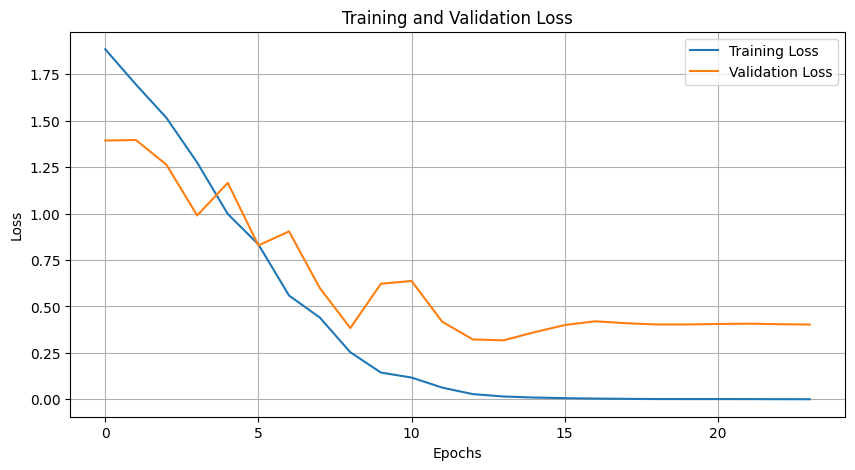

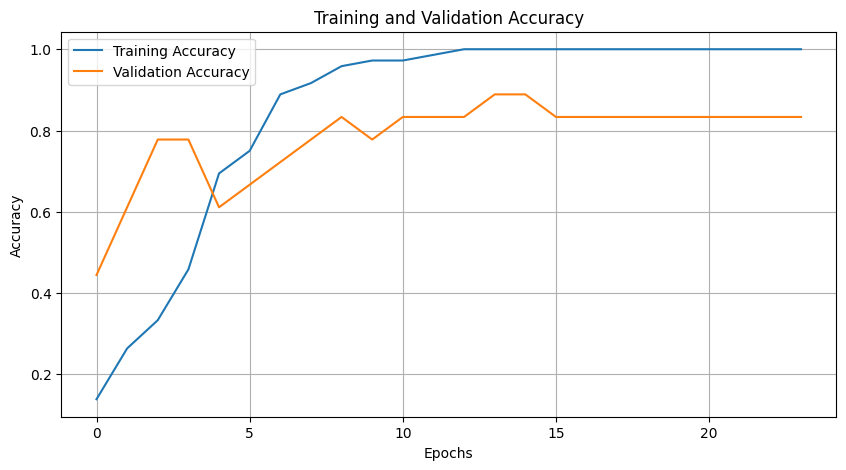

In [10]:
import matplotlib.pyplot as plt

# Extract training and validation metrics from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Create a figure for the loss graph
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Create a figure for the accuracy graph
plt.figure(figsize=(10, 5))
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()